<a href="https://colab.research.google.com/github/Tapopita/Desafio-3-Analisis-de-evacion-de-cleintes-parte-2.0/blob/main/Desafio_3_Analisis_de_evacion_de_cleintes_parte_2_Carlos_Aravena.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Preparacion

In [51]:
import pandas as pd
import numpy as np

# Cargar dataset tratado
ruta = "/content/TelecomX_limpio.csv"
df = pd.read_csv(ruta)

# Vista inicial
display(df.head())

print("Dimensiones del dataset:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


Dimensiones del dataset: (7256, 21)

Tipos de datos:
customerID           object
Churn                object
gender               object
SeniorCitizen        object
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
Charges.Monthly     float64
Charges.Total       float64
dtype: object


In [52]:
# Eliminar filas con valores nulos
df_modelo = df_modelo.dropna()

# Verificar nuevamente
print(df_modelo.isnull().sum())

Churn                                    0
tenure                                   0
Charges.Monthly                          0
Charges.Total                            0
gender_Male                              0
SeniorCitizen_Yes                        0
Partner_Yes                              0
Dependents_Yes                           0
PhoneService_Yes                         0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                       0
OnlineBackup_No internet service         0
OnlineBackup_Yes                         0
DeviceProtection_No internet service     0
DeviceProtection_Yes                     0
TechSupport_No internet service          0
TechSupport_Yes                          0
StreamingTV_No internet service          0
StreamingTV_Yes                          0
StreamingMo

In [53]:
print("Valores nulos por columna:")
print(df.isnull().sum())

print("\nDistribución de la variable objetivo:")
print(df["Churn"].value_counts())

print("\nPorcentaje de churn:")
print(df["Churn"].value_counts(normalize=True) * 100)

Valores nulos por columna:
customerID            0
Churn               224
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
Contract              0
PaperlessBilling      0
PaymentMethod         0
Charges.Monthly       0
Charges.Total         0
dtype: int64

Distribución de la variable objetivo:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Porcentaje de churn:
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


In [54]:
if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])

In [55]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
print(df["Churn"].value_counts())

Churn
0.0    5163
1.0    1869
Name: count, dtype: int64


In [56]:
print("Columnas categóricas:")
print(df.select_dtypes(include="object").columns.tolist())

Columnas categóricas:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [57]:
df_modelo = pd.get_dummies(df, drop_first=True)

print("Dimensiones después de codificación:", df_modelo.shape)
display(df_modelo.head())

Dimensiones después de codificación: (7256, 31)


,Churn,tenure,Charges.Monthly,Charges.Total,gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,9,65.6,593.30,False,False,True,True,True,False,...,False,True,False,False,True,False,True,False,False,True
1,0.0,9,59.9,542.40,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True
2,1.0,4,73.9,280.85,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
3,1.0,13,98.0,1237.85,True,True,True,False,True,False,...,False,True,False,True,False,False,True,False,True,False
4,1.0,3,83.9,267.40,False,True,True,False,True,False,...,False,True,False,False,False,False,True,False,False,True


2. Análisis de correlación

2.1 Matriz general

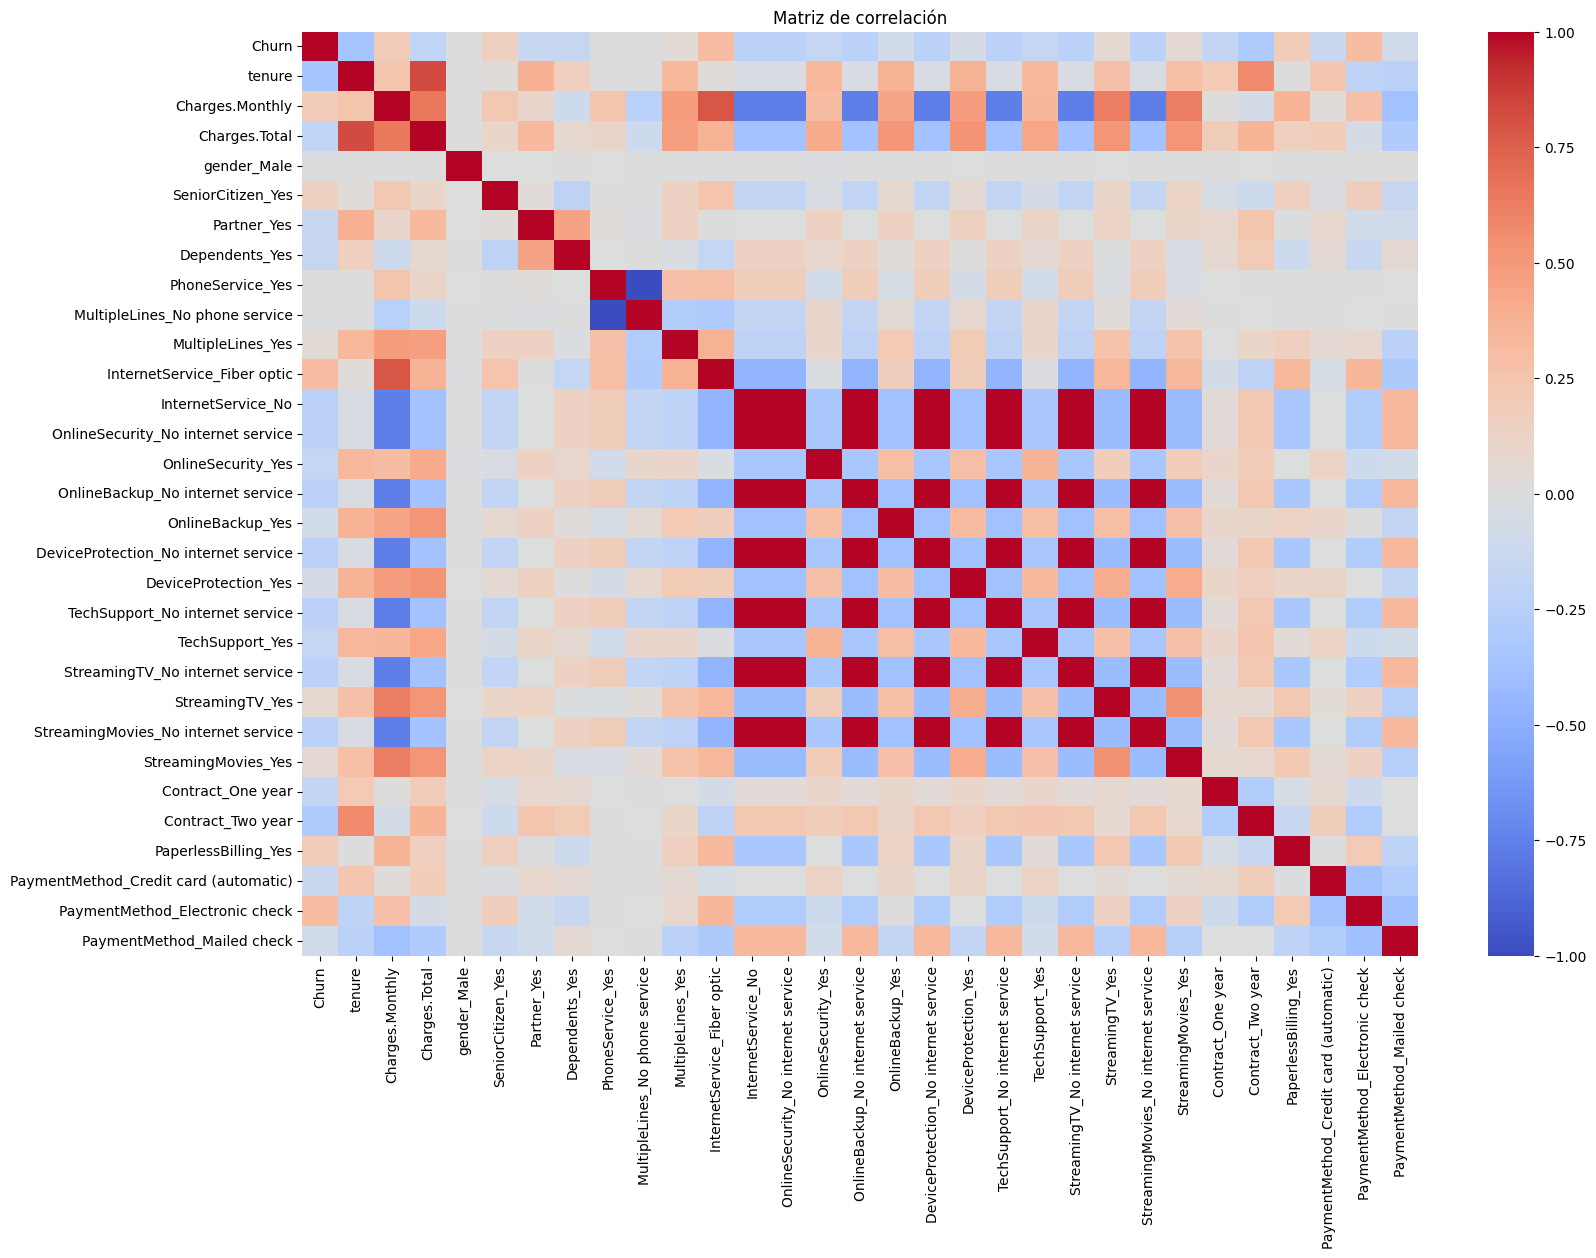

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 12))
sns.heatmap(df_modelo.corr(), cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.show()

2.2 Variables más correlacionadas con churn

In [59]:
corr_churn = df_modelo.corr()["Churn"].sort_values(ascending=False)

print("Correlación con Churn:")
print(corr_churn)

Correlación con Churn:
Churn                                    1.000000
InternetService_Fiber optic              0.307463
PaymentMethod_Electronic check           0.301455
Charges.Monthly                          0.192858
PaperlessBilling_Yes                     0.191454
SeniorCitizen_Yes                        0.150541
StreamingTV_Yes                          0.063254
StreamingMovies_Yes                      0.060860
MultipleLines_Yes                        0.040033
PhoneService_Yes                         0.011691
gender_Male                             -0.008545
MultipleLines_No phone service          -0.011691
DeviceProtection_Yes                    -0.066193
OnlineBackup_Yes                        -0.082307
PaymentMethod_Mailed check              -0.090773
PaymentMethod_Credit card (automatic)   -0.134687
Partner_Yes                             -0.149982
Dependents_Yes                          -0.163128
TechSupport_Yes                         -0.164716
OnlineSecurity_Yes         

2.3 Top variables más influyentes

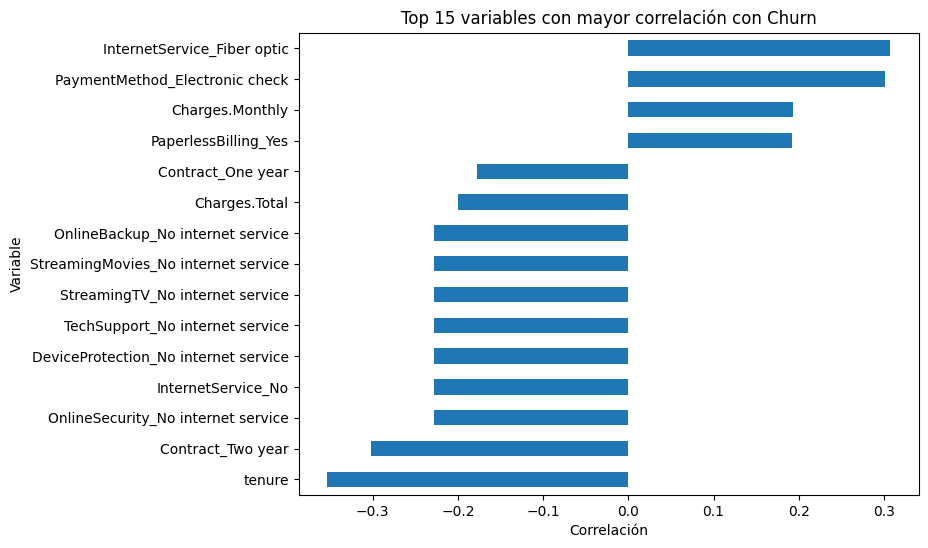

In [60]:
top_corr = df_modelo.corr()["Churn"].drop("Churn").sort_values(key=abs, ascending=False).head(15)

plt.figure(figsize=(8,6))
top_corr.sort_values().plot(kind="barh")
plt.title("Top 15 variables con mayor correlación con Churn")
plt.xlabel("Correlación")
plt.ylabel("Variable")
plt.show()

3. Separación entre variables predictoras y objetivo

In [61]:
# Eliminar filas con valores nulos
df_modelo = df_modelo.dropna()

# Verificar nuevamente
print(df_modelo.isnull().sum())

Churn                                    0
tenure                                   0
Charges.Monthly                          0
Charges.Total                            0
gender_Male                              0
SeniorCitizen_Yes                        0
Partner_Yes                              0
Dependents_Yes                           0
PhoneService_Yes                         0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                       0
OnlineBackup_No internet service         0
OnlineBackup_Yes                         0
DeviceProtection_No internet service     0
DeviceProtection_Yes                     0
TechSupport_No internet service          0
TechSupport_Yes                          0
StreamingTV_No internet service          0
StreamingTV_Yes                          0
StreamingMo

In [62]:
from sklearn.model_selection import train_test_split

X = df_modelo.drop("Churn", axis=1)
y = df_modelo["Churn"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4922, 30)
X_test: (2110, 30)
y_train: (4922,)
y_test: (2110,)


4. Estandarización

In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

5. Regresión logística

In [64]:
from sklearn.linear_model import LogisticRegression

modelo_log = LogisticRegression(max_iter=1000, random_state=42)
modelo_log.fit(X_train_scaled, y_train)

y_pred_log = modelo_log.predict(X_test_scaled)
y_prob_log = modelo_log.predict_proba(X_test_scaled)[:, 1]

6. Random Forest

In [65]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)
y_prob_rf = modelo_rf.predict_proba(X_test)[:, 1]

7. Evaluación de modelos

7.1 Función de evaluación

In [66]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

def evaluar_modelo(y_real, y_pred, y_prob, nombre):
    print(f"Modelo: {nombre}")
    print("-" * 40)
    print("Accuracy :", round(accuracy_score(y_real, y_pred), 4))
    print("Precision:", round(precision_score(y_real, y_pred), 4))
    print("Recall   :", round(recall_score(y_real, y_pred), 4))
    print("F1-score :", round(f1_score(y_real, y_pred), 4))
    print("ROC-AUC  :", round(roc_auc_score(y_real, y_prob), 4))
    print("\nReporte de clasificación:")
    print(classification_report(y_real, y_pred))

7.2 Evaluar regresión logística

In [67]:
evaluar_modelo(y_test, y_pred_log, y_prob_log, "Regresión Logística")

Modelo: Regresión Logística
----------------------------------------
Accuracy : 0.8033
Precision: 0.6573
Recall   : 0.5437
F1-score : 0.5951
ROC-AUC  : 0.8453

Reporte de clasificación:
              precision    recall  f1-score   support

         0.0       0.84      0.90      0.87      1549
         1.0       0.66      0.54      0.60       561

    accuracy                           0.80      2110
   macro avg       0.75      0.72      0.73      2110
weighted avg       0.79      0.80      0.80      2110



7.3 Evaluar random forest

In [68]:
evaluar_modelo(y_test, y_pred_rf, y_prob_rf, "Random Forest")

Modelo: Random Forest
----------------------------------------
Accuracy : 0.7867
Precision: 0.6377
Recall   : 0.4581
F1-score : 0.5332
ROC-AUC  : 0.8221

Reporte de clasificación:
              precision    recall  f1-score   support

         0.0       0.82      0.91      0.86      1549
         1.0       0.64      0.46      0.53       561

    accuracy                           0.79      2110
   macro avg       0.73      0.68      0.70      2110
weighted avg       0.77      0.79      0.77      2110



8. Matrices de confusión

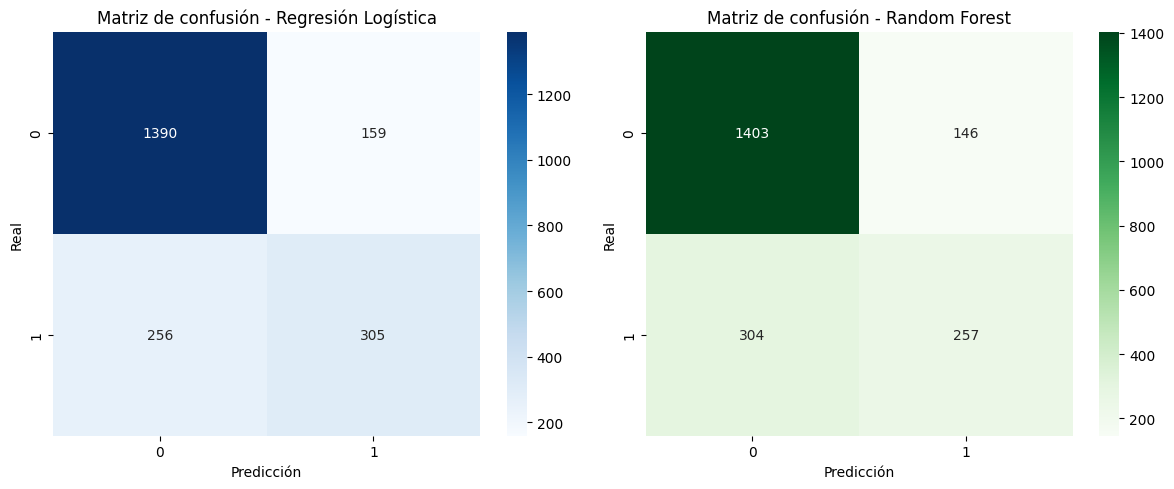

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Matriz de confusión - Regresión Logística")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Real")

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("Matriz de confusión - Random Forest")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Real")

plt.tight_layout()
plt.show()

9. Curva ROC

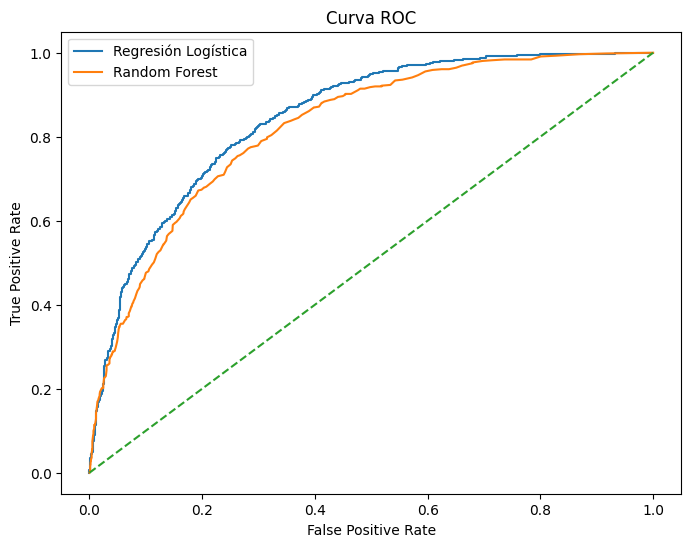

In [70]:
from sklearn.metrics import roc_curve

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, label="Regresión Logística")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()

10. Regresión logística

In [71]:
coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo_log.coef_[0]
})

coeficientes["AbsCoef"] = coeficientes["Coeficiente"].abs()
coeficientes = coeficientes.sort_values("AbsCoef", ascending=False)

display(coeficientes.head(15))

,Variable,Coeficiente,AbsCoef
0,tenure,-1.343554,1.343554
2,Charges.Total,0.626025,0.626025
10,InternetService_Fiber optic,0.594341,0.594341
25,Contract_Two year,-0.542835,0.542835
1,Charges.Monthly,-0.510416,0.510416
24,Contract_One year,-0.285491,0.285491
21,StreamingTV_Yes,0.201481,0.201481
28,PaymentMethod_Electronic check,0.183835,0.183835
26,PaperlessBilling_Yes,0.180289,0.180289
23,StreamingMovies_Yes,0.156266,0.156266


<Figure size 800x600 with 0 Axes>

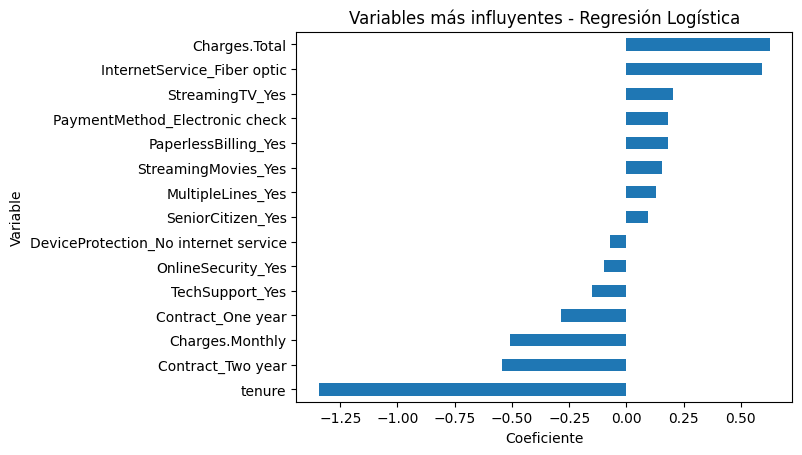

In [72]:
plt.figure(figsize=(8,6))
coeficientes.head(15).sort_values("Coeficiente").plot(
    x="Variable", y="Coeficiente", kind="barh", legend=False
)
plt.title("Variables más influyentes - Regresión Logística")
plt.xlabel("Coeficiente")
plt.ylabel("Variable")
plt.show()

11. Random Forest

In [73]:
importancias_rf = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo_rf.feature_importances_
}).sort_values("Importancia", ascending=False)

display(importancias_rf.head(15))

,Variable,Importancia
2,Charges.Total,0.171947
0,tenure,0.170332
1,Charges.Monthly,0.149625
25,Contract_Two year,0.057653
28,PaymentMethod_Electronic check,0.042087
10,InternetService_Fiber optic,0.040287
24,Contract_One year,0.028545
3,gender_Male,0.026356
13,OnlineSecurity_Yes,0.025415
26,PaperlessBilling_Yes,0.024260


<Figure size 800x600 with 0 Axes>

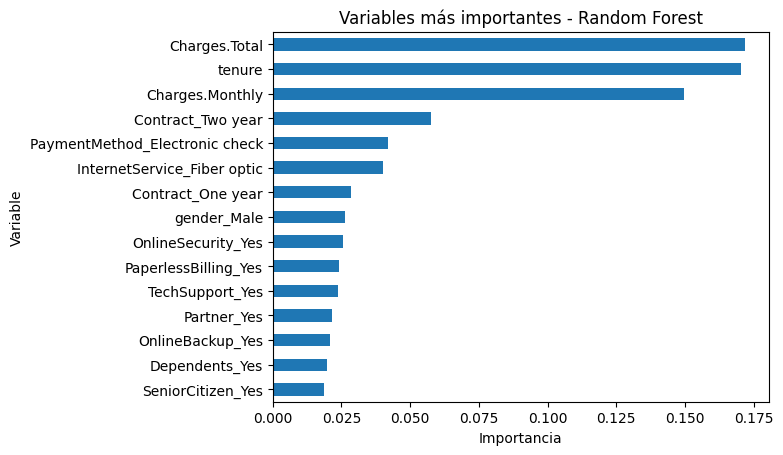

In [74]:
plt.figure(figsize=(8,6))
importancias_rf.head(15).sort_values("Importancia").plot(
    x="Variable", y="Importancia", kind="barh", legend=False
)
plt.title("Variables más importantes - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

12. Conclusión final

In [77]:
conclusion = """
Conclusión final

En este desafío se construyeron modelos predictivos para estimar la probabilidad de evasión de clientes en Telecom X, utilizando los datos previamente tratados en la Parte 1.

La preparación del dataset incluyó la eliminación de variables irrelevantes, la transformación de la variable objetivo, la codificación de variables categóricas y la separación entre conjuntos de entrenamiento y prueba.

A partir del análisis de correlación y de la importancia de variables en los modelos, se observó que la evasión se encuentra asociada principalmente a factores como el tipo de contrato, la antigüedad del cliente, los cargos mensuales y ciertos servicios complementarios.

La regresión logística permitió una interpretación clara de los factores que aumentan o reducen el riesgo de churn, mientras que Random Forest ofreció una comparación útil en términos de desempeño predictivo.

Desde una perspectiva estratégica, Telecom X debería enfocar sus esfuerzos de retención especialmente en:
- clientes con contratos mensuales,
- clientes con poca antigüedad,
- clientes con cargos mensuales altos,
- clientes sin servicios adicionales de soporte, seguridad o respaldo.

Estos hallazgos permiten identificar perfiles de mayor riesgo y generar acciones preventivas más focalizadas, lo que puede reducir la pérdida de clientes y mejorar la retención.
"""
print(conclusion)


Conclusión final

En este desafío se construyeron modelos predictivos para estimar la probabilidad de evasión de clientes en Telecom X, utilizando los datos previamente tratados en la Parte 1.

La preparación del dataset incluyó la eliminación de variables irrelevantes, la transformación de la variable objetivo, la codificación de variables categóricas y la separación entre conjuntos de entrenamiento y prueba.

A partir del análisis de correlación y de la importancia de variables en los modelos, se observó que la evasión se encuentra asociada principalmente a factores como el tipo de contrato, la antigüedad del cliente, los cargos mensuales y ciertos servicios complementarios.

La regresión logística permitió una interpretación clara de los factores que aumentan o reducen el riesgo de churn, mientras que Random Forest ofreció una comparación útil en términos de desempeño predictivo.

Desde una perspectiva estratégica, Telecom X debería enfocar sus esfuerzos de retención especialmente 